# Chunking-eval report — `study-A-fit`

## 1 — Setup

In [1]:
# This notebook runs end-to-end given a study YAML config. Change the
# constant below to switch studies; everything else derives from it.
import os
import sys
from pathlib import Path

# When running from the notebook (cwd = notebooks/), reach the src/ layout.
REPO_ROOT = Path(os.environ.get("IMPRESSO_REPO_ROOT", Path.cwd().resolve())).resolve()
if (REPO_ROOT / "notebooks").is_dir() is False and (REPO_ROOT.parent / "notebooks").is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

STUDY_CONFIG_PATH = REPO_ROOT / "configs/research/study-A-fit.yaml"
assert STUDY_CONFIG_PATH.exists(), f"missing: {STUDY_CONFIG_PATH}"
print(f"study config: {STUDY_CONFIG_PATH}")

study config: /Users/adrien/Documents/nlp2/impresso-text-embedder/configs/research/study-A-fit.yaml


In [2]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from impresso_text_embedder.research import eval as ev
from impresso_text_embedder.research.scenario_builder import ScenarioRegistry
from impresso_text_embedder.research.study_config import load_study_config

# Minimal-noise log surface so notebook output stays readable.
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
logging.getLogger("impresso_text_embedder").setLevel(logging.INFO)
logging.getLogger("botocore").setLevel(logging.WARNING)
logging.getLogger("s3transfer").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)

# Best-practice seaborn theme: white grid for ratio plots, colorblind palette
# (categorical axis = chunker family), tight context. dpi bumped so PNGs in
# the rendered notebook are readable at GitHub's render width without
# blowing up the file size.
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="colorblind",
    rc={"figure.dpi": 110, "savefig.dpi": 130, "axes.titleweight": "bold"},
)

In [3]:
study_cfg = load_study_config(STUDY_CONFIG_PATH)
registry = ScenarioRegistry.from_study(study_cfg)
print(f"study={study_cfg.study.name}  config_sha={study_cfg.config_sha}")
print(f"languages={study_cfg.corpus.languages}  n_per_lg={study_cfg.corpus.n_per_lg}")
print(f"scenarios ({len(registry.all_ids())}):")
print(registry.format_table())

study=A-fit  config_sha=77298a7b9955
languages=('fr', 'de')  n_per_lg=300
scenarios (9):
id    chunker        chunk_tokens  label
----------------------------------------
S0    (none)                    -  truncate-8192
S1    fixed-window            512  fixed-window-512
S2    fixed-window           1024  fixed-window-1024
S3    fixed-window           2048  fixed-window-2048
S4    fixed-window           4096  fixed-window-4096
S5    token-budget            512  token-budget-512
S6    token-budget           1024  token-budget-1024
S7    token-budget           2048  token-budget-2048
S8    token-budget           4096  token-budget-4096


## 2 — Load eval inputs

Pulls the queries-embedded shard plus every scenario shard for this study
from `s3://{study_cfg.s3.bucket}/{study_cfg.study_s3_root()}/`. Files cache
under the local mirror (`study_cfg.local_path(...)`); re-running the cell
hits the cache. Pass `force=True` to invalidate.

In [4]:
corpus = ev.load_corpus(study_cfg)

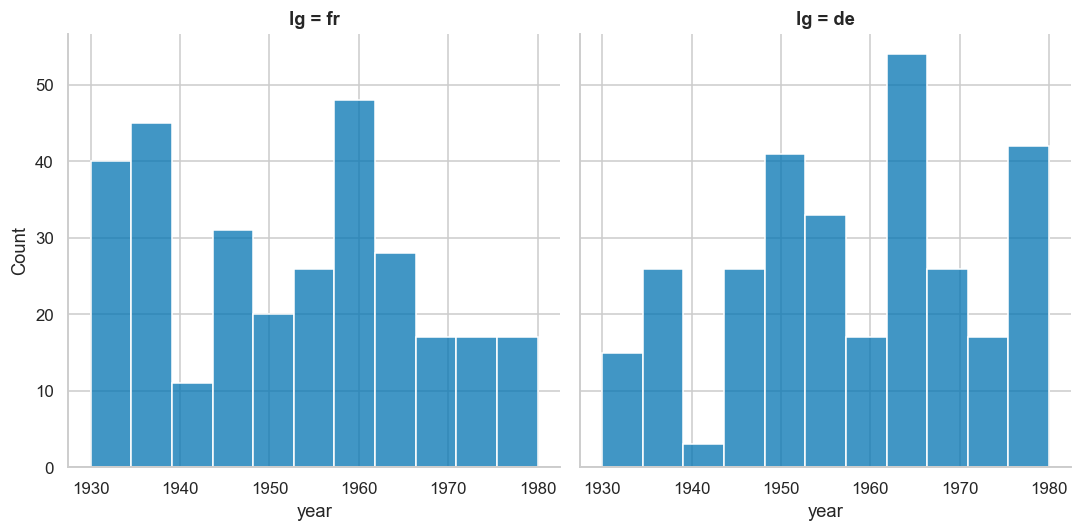

In [5]:
df_corpus =pd.DataFrame(data=corpus).set_index("ci_id")
sns.displot(data=df_corpus, x="year", col="lg")

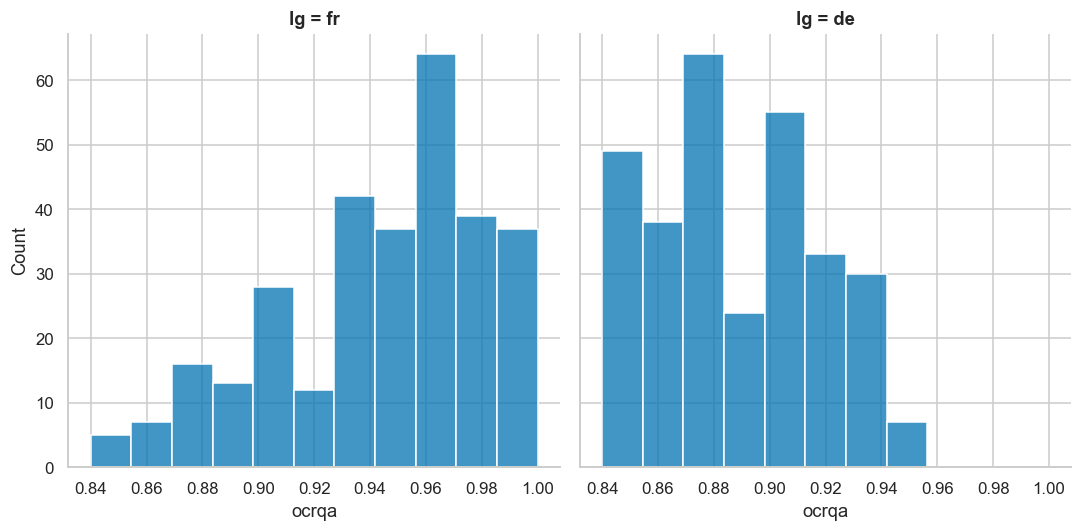

In [6]:
sns.displot(data=df_corpus, x="ocrqa", col="lg")

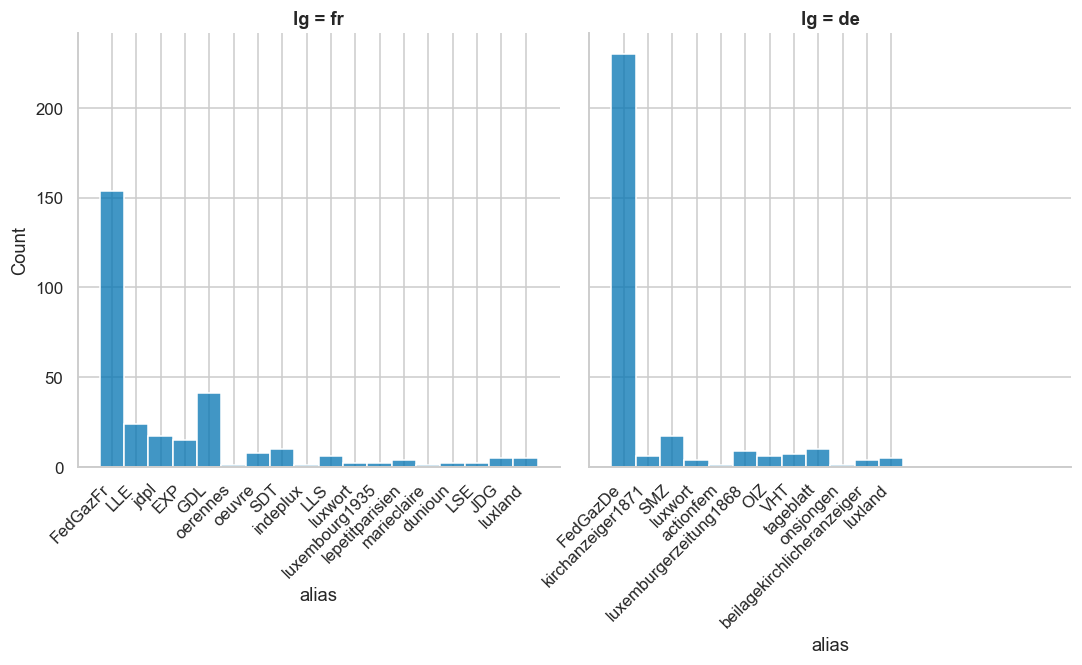

In [7]:
# The 'sharex=False' is the key here
g = sns.displot(
    data=df_corpus, 
    x="alias", 
    col="lg", 
    kind="hist",
    facet_kws={'sharex': False}
)

# Apply rotation to all axes in the grid
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

In [8]:
inputs = ev.load_eval_inputs(study_cfg)
print(
    f"loaded {len(inputs.queries)} queries × {len(inputs.pools)} scenarios "
    f"({sum(p.embeddings.shape[0] for p in inputs.pools.values())} doc rows total)"
)

loaded 3343 queries × 9 scenarios (5400 doc rows total)


In [9]:
df = pd.DataFrame(np.array([inputs.pools["S2"].langs, inputs.pools["S2"].n_tokens, inputs.pools["S2"].len_chars]).T, columns=["lg", "n_tokens", "len_chars"])
df["ratio"] = df["len_chars"] / df["n_tokens"]

/var/folders/4m/l5rkp4s94jg_fr07xhlzksb00000gs/T/ipykernel_86199/708938885.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.displot(data=df, x="n_tokens", col="lg", palette="colorblind")


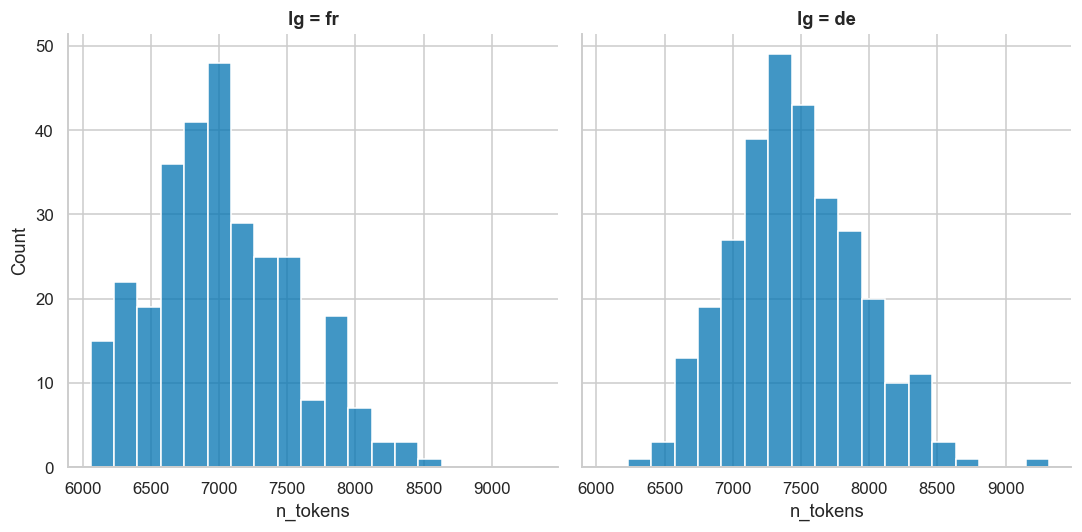

In [10]:
sns.displot(data=df, x="n_tokens", col="lg", palette="colorblind")

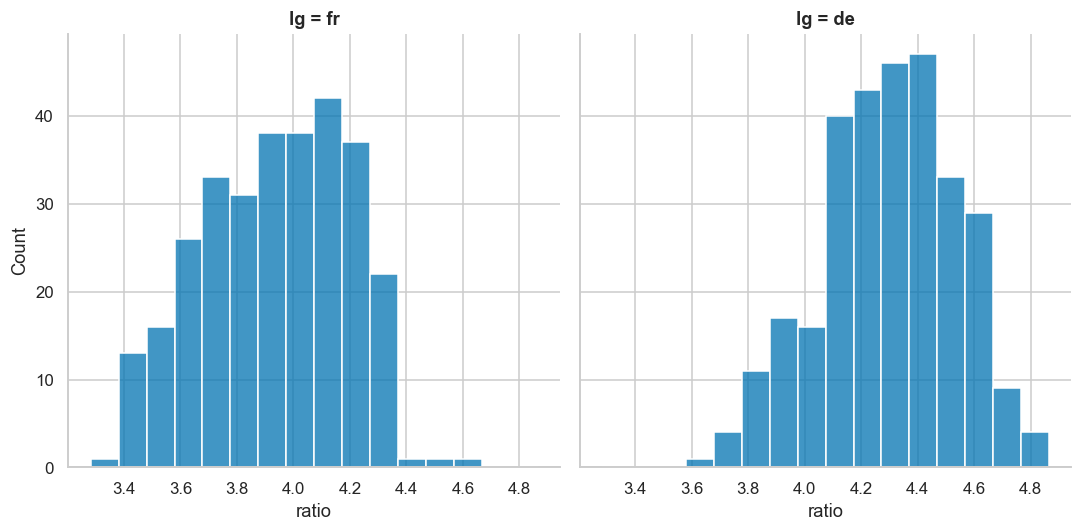

In [11]:
sns.displot(data=df, x="ratio", col="lg")

In [12]:
import html                                                                                                                                                                                                                                                                      
from IPython.display import HTML, display                                                                                                                                                                                                                                        
                                                                                                                                                                                                                                                                                
_PALETTE = {                            
    "question":       {"tag": "#3b82f6", "bucket": "rgba(59,130,246,0.18)", "ref": "#fde68a"},
    "topical-phrase": {"tag": "#f97316", "bucket": "rgba(249,115,22,0.18)", "ref": "#fdba74"},                                                                                                                                                                                   
}                                                                                                                                                                                                                                                                                
def render_query_in_corpus(c, q) -> HTML:                                                                                                                                                                                                                                        
    pal = _PALETTE.get(q.query_type, _PALETTE["question"])
    b_start, b_end = q.position_chars   
    refs = sorted(                                                                                                                                                                                                                                                               
        ((r["char_start"], r["char_end"], r["text"]) for r in q.references),
        key=lambda t: t[0],                                                                                                                                                                                                                                                      
    )                                
                                                                                                                                                                                                                                                                                
    prefix = "…" if b_start > 0 else ""
    suffix = "…" if b_end < len(c.ft) else ""                                                                                                                                                                                                                                    
                                    
    events: list[tuple[int, int, str]] = []                                                                                                                                                                                                                                      
    for s, e, _ in refs:          
        events.append((s, 0, "open"))                                                                                                                                                                                                                                            
        events.append((e, 1, "close"))
    events.sort(key=lambda x: (x[0], x[1]))
                                                                                                                                                                                                                                                                                
    ref_style = (f"background:{pal['ref']};color:#111;font-weight:600;"
                f"padding:0 2px;border-radius:2px;")                                                                                                                                                                                                                            
                                                                                                                                                                                                                                                                                
    out = [f'<span style="opacity:.55">{prefix}</span>']
    cursor = b_start                                                                                                                                                                                                                                                             
    for pos, _, kind in events:       
        pos = max(b_start, min(b_end, pos))
        if pos > cursor:                                                                                                                                                                                                                                                         
            out.append(html.escape(c.ft[cursor:pos]))
            cursor = pos                                                                                                                                                                                                                                                         
        out.append(f'<span style="{ref_style}">' if kind == "open" else "</span>")
    if cursor < b_end:                                                                                                                                                                                                                                                           
        out.append(html.escape(c.ft[cursor:b_end]))
    out.append(f'<span style="opacity:.55">{suffix}</span>')                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                                                
    header = (                                                                                                                                                                                                                                                                   
        f'<div style="font:13px/1.45 -apple-system,Segoe UI,Helvetica,sans-serif;'
        f'border-left:4px solid {pal["tag"]};padding:10px 14px;margin:12px 0 0;'                                                                                                                                                                                                 
        f'background:rgba(127,127,127,0.10);border-radius:0 4px 0 0">'                                                                                                                                                                                                           
        f'<div style="color:{pal["tag"]};font-weight:700;text-transform:uppercase;'                                                                                                                                                                                              
        f'letter-spacing:.05em;font-size:11px;margin-bottom:6px">'                                                                                                                                                                                                               
        f'{html.escape(q.query_type)} · {html.escape(q.position_bucket)} '                                                                                                                                                                                                       
        f'[{b_start}:{b_end}] · {b_end - b_start:,} chars · {len(refs)} ref(s)</div>'
        f'<div style="font-size:15px;line-height:1.4">'                                                                                                                                                                                                                          
        f'<span style="opacity:.5">Q.</span> {html.escape(q.query_text)}</div>'
        f'<div style="opacity:.55;font-size:11px;margin-top:6px;font-variant-numeric:tabular-nums">'                                                                                                                                                                             
        f'<a href="https://impresso-project.ch/app/article/{html.escape(c.ci_id)}" '                                                                                                                                                                                             
        f'target="_blank" rel="noopener" '                                                                                                                                                                                                                                       
        f'style="color:inherit;text-decoration:none;border-bottom:1px dotted currentColor">'                                                                                                                                                                                     
        f'<code style="background:rgba(127,127,127,.15);padding:1px 4px;border-radius:3px">'                                                                                                                                                                                     
        f'{html.escape(c.ci_id)}</code>&nbsp;↗</a>'                                                                                                                                                                                                                              
        f' · lg={html.escape(c.lg)} '                                                                                                                                                                                                                                            
        f'· len_chars={len(c.ft):,}</div></div>'                                                                                                                                                                                                                                 
    )                                       
    body = (                                                                                                                                                                                                                                                                     
        f'<div style="font:15px/1.7 Georgia,Charter,Cambria,serif;'                                                                                                                                                                                                              
        f'white-space:pre-wrap;word-break:break-word;'
        f'padding:14px 16px;margin:0 0 14px;'                                                                                                                                                                                                                                    
        f'border:1px solid rgba(127,127,127,.25);border-top:none;'                                                                                                                                                                                                               
        f'border-radius:0 0 4px 4px;max-height:520px;overflow-y:auto">'
        f'{"".join(out)}</div>'                                                                                                                                                                                                                                                  
    )                                 
    return HTML(header + body) 

def find_query(queries, ci_id, position, query_type):                                                                                                                                                                                                                            
    for q in queries:
        if q.ci_id == ci_id and q.position_bucket == position and q.query_type == query_type:                                                                                                                                                                                    
            return q                 
    raise LookupError(f"no {query_type}/{position} query for {ci_id}")      

i = 3
position = "mid"
query_type = "question"

display(
    render_query_in_corpus(
        corpus[i],
        find_query(inputs.queries, corpus[i].ci_id, position, query_type), )
    )

## 3 — Sanity checks

Every assertion here is a load-time guard against an upstream pipeline drift
that would silently invalidate the eval (mismatched embedding dim, scenarios
covering different `ci_id` sets, queries whose gold doc is absent, non-finite
or non-unit-norm embeddings). The `Issues` row is empty when everything is
green.

In [13]:
report = ev.run_sanity(inputs)

summary_rows = [
    ("queries (total)", report.n_queries),
    ("query languages", report.n_query_languages),
    ("embedding dim", report.embedding_dim),
    ("queries by lg", report.queries_lg_counts),
    ("queries by position bucket", report.queries_position_counts),
    ("queries by query_type", report.queries_type_counts),
    ("pool size per scenario", report.pool_size_per_scenario),
    ("pool lg counts (S0)", report.pool_lg_counts_per_scenario.get("S0", {})),
    ("queries with unmatched ci_id", len(report.queries_with_unmatched_ci_id)),
    ("Issues", report.issues or "(none)"),
]
sanity_df = pd.DataFrame(summary_rows, columns=["check", "value"])
sanity_df.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
)

,check,value
0,queries (total),3343
1,query languages,2
2,embedding dim,768
3,queries by lg,"{'fr': 1663, 'de': 1680}"
4,queries by position bucket,"{'head': 1058, 'mid': 1134, 'tail': 1151}"
5,queries by query_type,"{'question': 1678, 'topical-phrase': 1665}"
6,pool size per scenario,"{'S0': 600, 'S1': 600, 'S2': 600, 'S3': 600, 'S4': 600, 'S5': 600, 'S6': 600, 'S7': 600, 'S8': 600}"
7,pool lg counts (S0),"{'de': 300, 'fr': 300}"
8,queries with unmatched ci_id,0
9,Issues,(none)


In [14]:
assert report.passed, f"sanity failed: {report.issues}"

## 4 — Score every (query, scenario)

`score_queries` joins each query against the same-language slice of every
scenario's doc pool, computes the cosine rank of the gold `ci_id`, and emits
a tidy DataFrame with one row per `(query_id, scenario_id)`. Persisted to
parquet so re-running the plotting cells doesn't re-score.

In [15]:
scores = ev.score_queries(inputs, k_values=(1, 5, 10))
out_dir = study_cfg.study_local_root() / "eval"
out_dir.mkdir(parents=True, exist_ok=True)
parquet_path = out_dir / "scores.parquet"
#scores.to_parquet(parquet_path, index=False)
#print(f"wrote {len(scores):,} score rows -> {parquet_path}")
scores.head()

,query_id,ci_id,lg,query_type,position_bucket,scenario_id,scenario_label,chunker,chunk_tokens,aggregator,...,n_tokens,len_chars,rank,reciprocal_rank,margin,nll,recall_at_1,recall_at_5,recall_at_10,token_bucket
0,FedGazFr-1930-03-26-a-i0002__head__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,head,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.037988,2.606313,True,True,True,6k-8k
1,FedGazFr-1930-03-26-a-i0002__mid__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,mid,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.080609,1.88644,True,True,True,6k-8k
2,FedGazFr-1930-03-26-a-i0002__mid__topical-phra...,FedGazFr-1930-03-26-a-i0002,fr,topical-phrase,mid,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.077161,2.057157,True,True,True,6k-8k
3,FedGazFr-1930-03-26-a-i0002__tail__question__00,FedGazFr-1930-03-26-a-i0002,fr,question,tail,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.084081,1.780009,True,True,True,6k-8k
4,FedGazFr-1930-03-26-a-i0002__tail__topical-phr...,FedGazFr-1930-03-26-a-i0002,fr,topical-phrase,tail,S0,truncate-8192,truncate,<NA>,(none),...,6378,27134,1.0,1.0,0.042023,2.532672,True,True,True,6k-8k


In [ ]:
# Order scenarios by registry position so every plot keeps the same x-axis.
SCENARIO_ORDER = registry.all_ids()
SCENARIO_LABELS = {s.id: f"{s.id} · {s.label}" for s in registry.all_scenarios()}
CHUNKER_ORDER = ["truncate", "fixed-window", "token-budget"]
LG_ORDER = list(study_cfg.corpus.languages)

# Long display labels render better on rotated x-axes than ids alone.
scores["scenario_display"] = scores["scenario_id"].map(SCENARIO_LABELS)
scenario_display_order = [SCENARIO_LABELS[s] for s in SCENARIO_ORDER]

## 2 — Margin to Goal

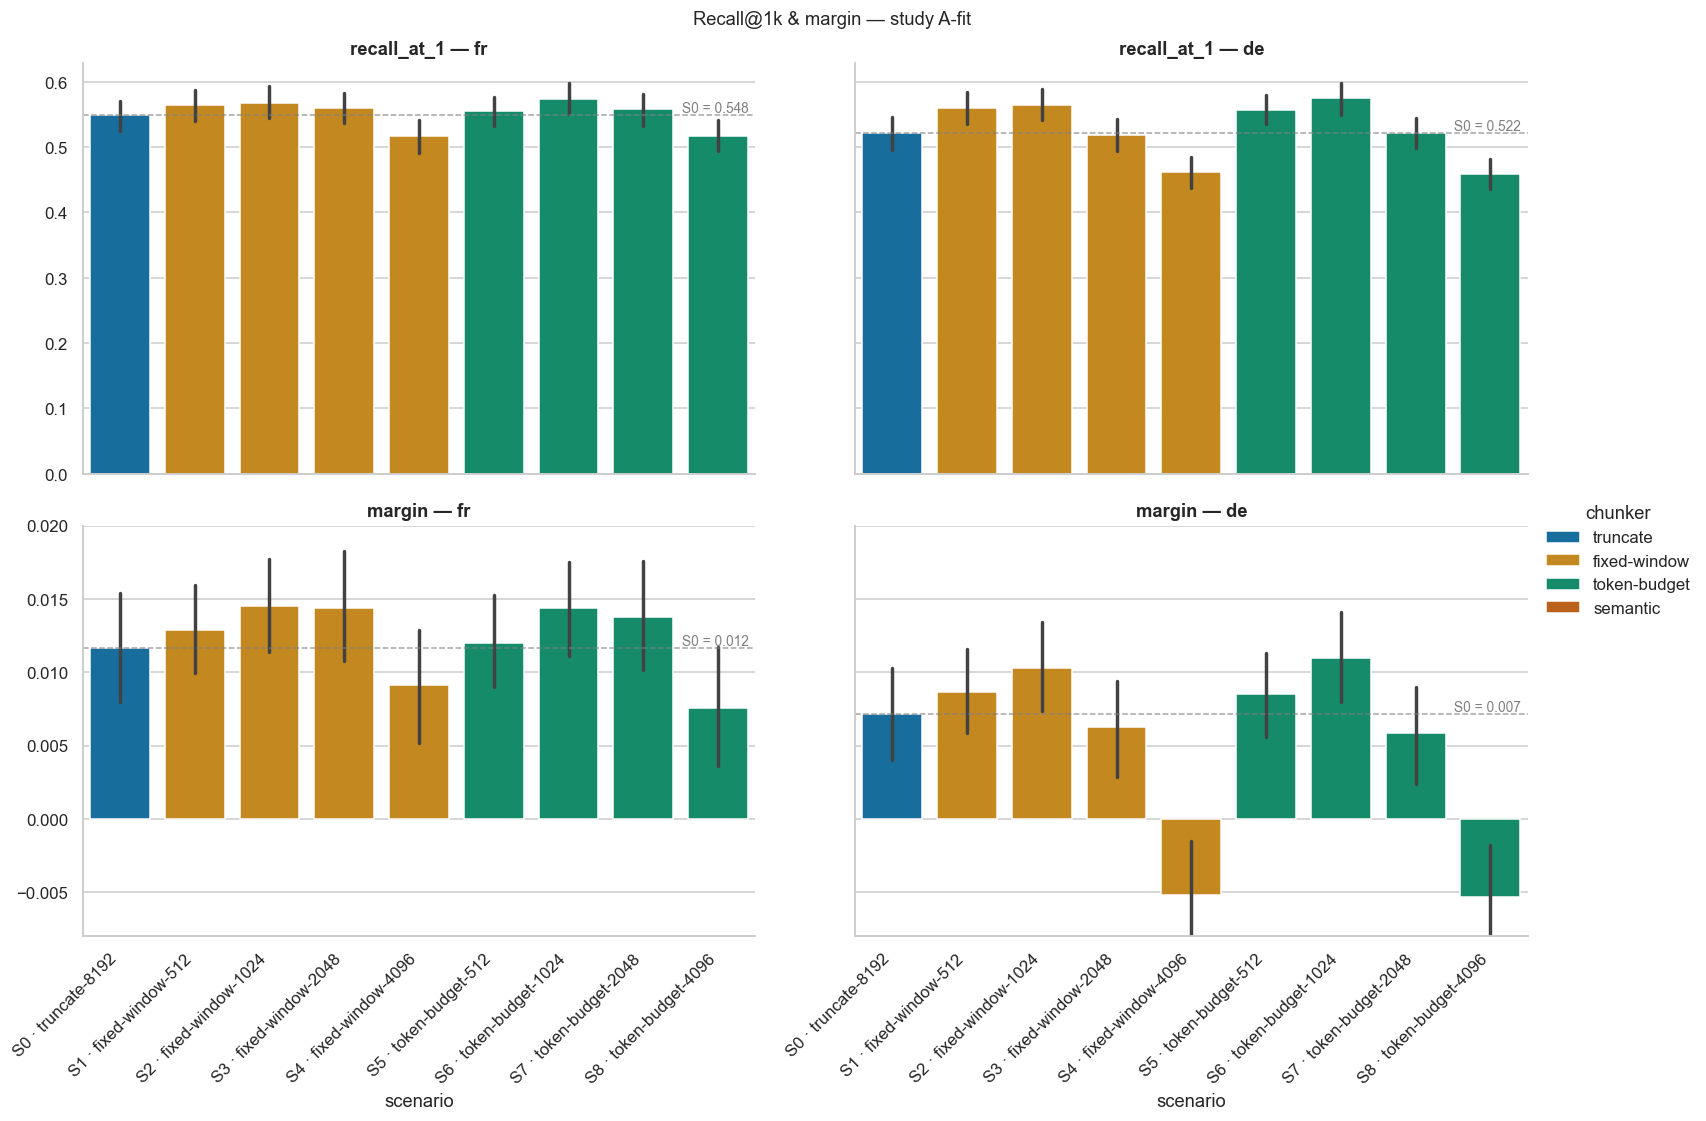

In [17]:
def _palette_for_chunkers():
    base = sns.color_palette("colorblind", n_colors=len(CHUNKER_ORDER))
    return dict(zip(CHUNKER_ORDER, base, strict=True))

chunker_palette = _palette_for_chunkers()

long = scores.melt(
    id_vars=["scenario_display", "scenario_id", "chunker", "lg"],                                                                                                                                                                                                                                                 
    value_vars=["recall_at_1", "margin"],                                                                                                                                                                                                                                                                            
    var_name="metric", value_name="value",                                                                                                                                                                                                                                                                        
)                                                                                                                                                                                                                                                                                                                 
                                        
g = sns.catplot(                                                                                                                                                                                                                                                                                                  
    data=long,                         
    x="scenario_display", y="value",    
    hue="chunker", hue_order=CHUNKER_ORDER, palette=chunker_palette,
    row="metric", row_order=["recall_at_1", "margin"],                                                                                                                                                                                                                                                               
    col="lg", col_order=LG_ORDER,                                                                                                                                                                                                                                                                                 
    kind="bar", order=scenario_display_order,                                                                                                                                                                                                                                                                     
    errorbar=("ci", 95),                                                                                                                                                                                                                                                                                          
    height=4.5, aspect=1.6, dodge=False,
    sharey="row",  # each metric keeps its own y-scale                                                                                                                                                                                                                                                            
    legend_out=True,                                                                                                                                                                                                                                                                                              
)                                                                                                                                                                                                                                                                                                                 
g.set_titles("{row_name} — {col_name}")       
g.set_axis_labels("scenario", "")     

                                    
for (metric, lg), ax in g.axes_dict.items():                                                                                                                                                                                                                                                                      
    s0 = float(scores[(scores.lg == lg) & (scores.scenario_id == "S0")][metric].mean())
    ax.axhline(s0, ls="--", color="gray", lw=1, alpha=0.7)                                                                                                                                                                                                                                                        
    ax.text(0.99, s0, f" S0 = {s0:.3f}",
            transform=ax.get_yaxis_transform(),                                                                                                                                                                                                                                                                   
            ha="right", va="bottom", color="gray", fontsize=9)
    if metric == "margin":                                                                                                                                                                                                                                                                                        
        ax.set_ylim(-0.008, 0.02)

g.set_axis_labels("scenario", "") 
for ax in g.axes[-1]: 
    ax.tick_params(axis="x", labelbottom=True)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")    
                                                                                                                                                                                                                                                                                                                
g.figure.suptitle(f"Recall@1k & margin — study {study_cfg.study.name}",                                                                                                                                                                                                                                           
                y=1.01, fontsize=12)  
plt.show()    

## 8 — Position-bucket robustness

The whole point of step 4's head/mid/tail bucketing: a chunker that always
keeps the head but loses the tail should show a tail-bucket cliff here. For
study-A-fit (docs ≤ context) we expect S0 to be roughly position-flat;
chunkers may differ.

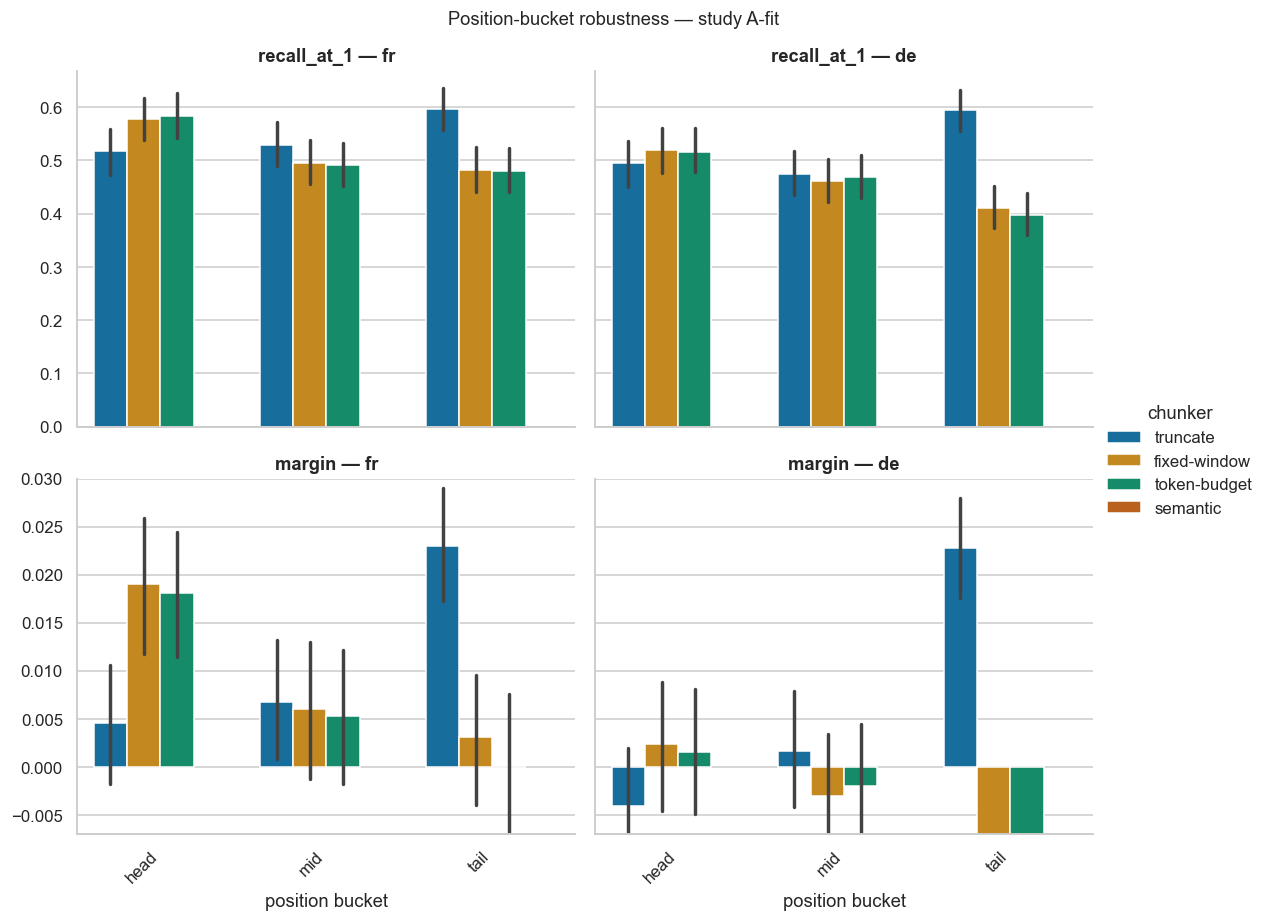

In [18]:
position_order = list(study_cfg.query_generation.position_buckets)
                                                                                                                                                                                                                                                                                                                
long = scores[scores['chunk_tokens'].isin([pd.NA, 4096])].melt(
    id_vars=["position_bucket", "chunker", "lg"],                                                                                                                                                                                                                                                                 
    value_vars=["recall_at_1", "margin"],                                                                                                                                                                                                                                                                            
    var_name="metric", value_name="value",
)                                                                                                                                                                                                                                                                                                                 
                                        
g = sns.catplot(                        
    data=long,                    
    x="position_bucket", y="value",                                                                                                                                                                                                                                                                               
    hue="chunker", hue_order=CHUNKER_ORDER, palette=chunker_palette,
    row="metric", row_order=["recall_at_1", "margin"],                                                                                                                                                                                                                                                            
    col="lg", col_order=LG_ORDER,                                                                                                                                                                                                                                                                                 
    order=position_order,               
    kind="bar",                                                                                                                                                                                                                                                                                                   
    height=4, aspect=1.3,              
    errorbar=("ci", 95),                                                                                                                                                                                                                                                                                          
    sharey="row",                 
)                                                                                                                                                                                                                                                                                                                 
g.set_titles("{row_name} — {col_name}")
g.set_axis_labels("position bucket", "")                                                                                                                                                                                                                                                                          
                                
for (metric, _lg), ax in g.axes_dict.items():                                                                                                                                                                                                                                                                     
    if metric == "margin":           
        ax.set_ylim(-0.007, 0.03)                                                                                                                                                                                                                                                                                 
                                                                                                                                                                                                                                                                                                                
for ax in g.axes[-1]:  # bottom row only
    ax.tick_params(axis="x", labelbottom=True)                                                                                                                                                                                                                                                                    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
                                                                                                                                                                                                                                                                                                                
g.figure.suptitle(                
    f"Position-bucket robustness — study {study_cfg.study.name}",                                                                                                                                                                                                                                                 
    y=1.02, fontsize=12,                                                                                                                                                                                                                                                                                          
)                                       
plt.show()     

## 10 — Query-type ablation

Closes O9 — does `question` retrieve differently than `topical-phrase`? If
one type dominates the signal (e.g. `topical-phrase` is the only metric the
chunker affects), the eval can stratify on it for the verdict.

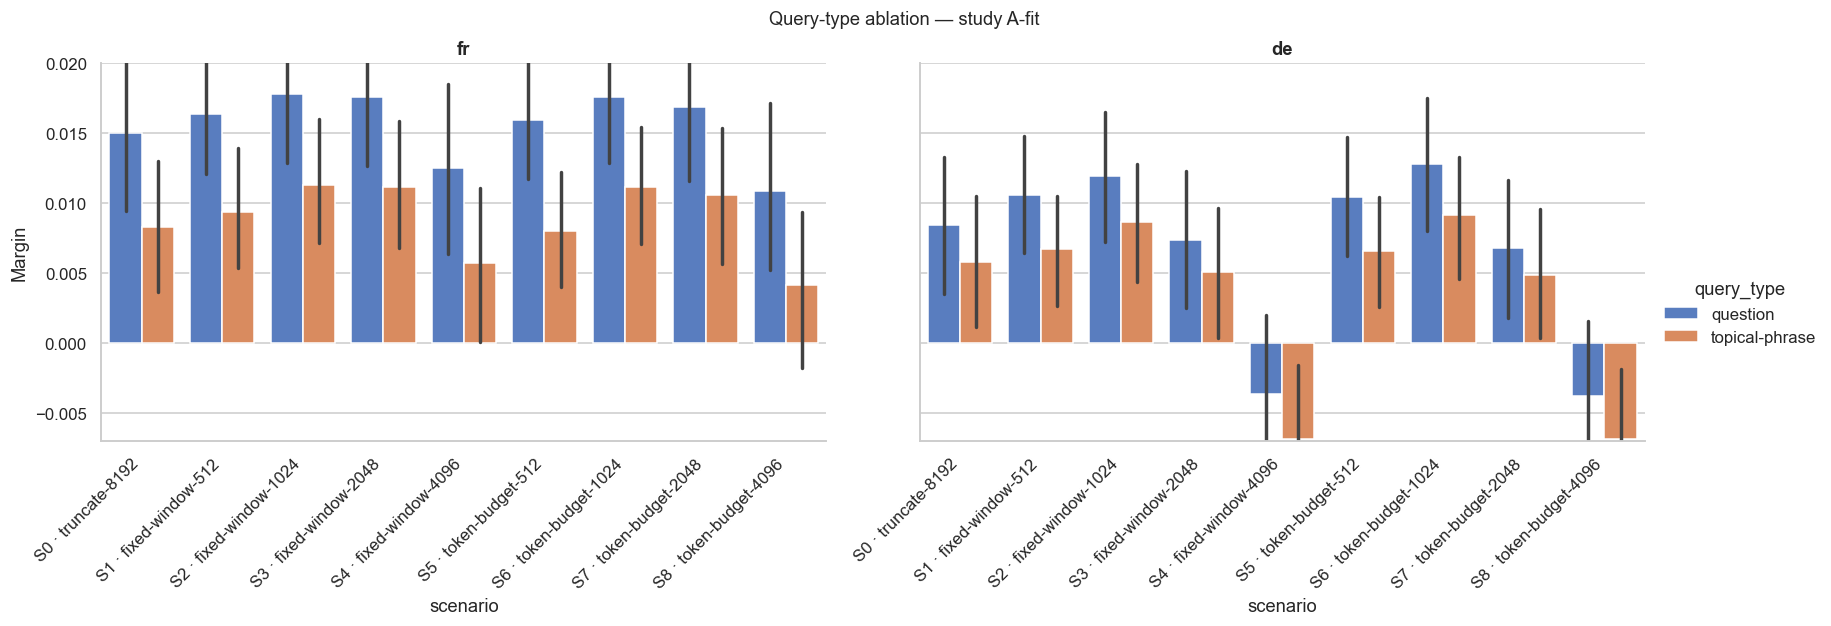

In [19]:
g = sns.catplot(
    data=scores,
    x="scenario_display",
    y="margin",
    hue="query_type",
    palette="muted",
    col="lg",
    col_order=LG_ORDER,
    order=scenario_display_order,
    kind="bar",
    height=4.5,
    aspect=1.7,
    errorbar=("ci", 95),
)
g.set_titles("{col_name}")
g.set_xticklabels(rotation=45, ha="right")
g.set_axis_labels("scenario", "Margin")
for ax in g.axes.flat:
    ax.set_ylim(-0.007, 0.02)
g.figure.suptitle(
    f"Query-type ablation — study {study_cfg.study.name}",
    y=1.02, fontsize=12,
)
plt.show()

#### 11c-ii — Truncation loss on the S0 baseline

`S0` truncates at `model.max_seq_length` (8190 for `gte-multilingual-base`).
For every gold doc with `n_tokens > 8190`, S0 silently drops the tail. This
table reports per-language, per-token-bucket: how often it happened, mean
tokens dropped, and Recall@5 within the bucket so we can see whether the
truncated docs are also the docs S0 fails on.

In [20]:
df = pd.DataFrame(np.array([inputs.pools["S2"].langs, inputs.pools["S2"].n_tokens, inputs.pools["S2"].len_chars]).T, columns=["lg", "n_tokens", "len_chars"])
df["ratio"] = df["len_chars"] / df["n_tokens"]
df[["ratio", "lg"]].groupby("lg").agg(["count", "mean", "std", "min", ("p10", lambda s: float(s.quantile(0.10))), ("p50", lambda s: float(s.median())), ("p90", lambda s: float(s.quantile(0.90))), "max"])    

ratio                                                                      
   count      mean       std       min       p10       p50       p90       max
lg                                                                            
de   300  4.301297  0.239473  3.607833  3.965438  4.314165  4.596857  4.864672
fr   300  3.933344  0.253148  3.282444  3.587903  3.957991  4.244378  4.576544

#### 11c-iii — Chunk-size distribution & padding overhead

For every chunked scenario (S0 excluded), explodes `n_tokens_per_chunk` into
one row per chunk and reports: violin plot of actual chunk size, plus a
summary table with `stub_count` (chunks under 256 tokens — the pathology
where the trailing fragment drags the mean off-course), `padding_pct`
(fraction of the target window left empty on average), and `cv` (coefficient
of variation; high cv = uneven chunker — sentence-aware chunkers tend to
spike here on long-headline OCR).

chunk-size distribution per scenario
scenario_id      chunker  chunk_tokens_target  count   mean  stub_count  padding_pct  cv
         S1 fixed-window                  512   8787  494.2         300          3.5 0.2
         S2 fixed-window                 1024   4546  955.1         155          6.7 0.2
         S3 fixed-window                 2048   2419 1794.7          48         12.4 0.3
         S4 fixed-window                 4096   1227 3538.1          19         13.6 0.2
         S5 token-budget                  512   9184  473.1         319          7.6 0.2
         S6 token-budget                 1024   4634  937.7         140          8.4 0.2
         S7 token-budget                 2048   2431 1787.5          37         12.7 0.3
         S8 token-budget                 4096   1231 3529.9          19         13.8 0.2



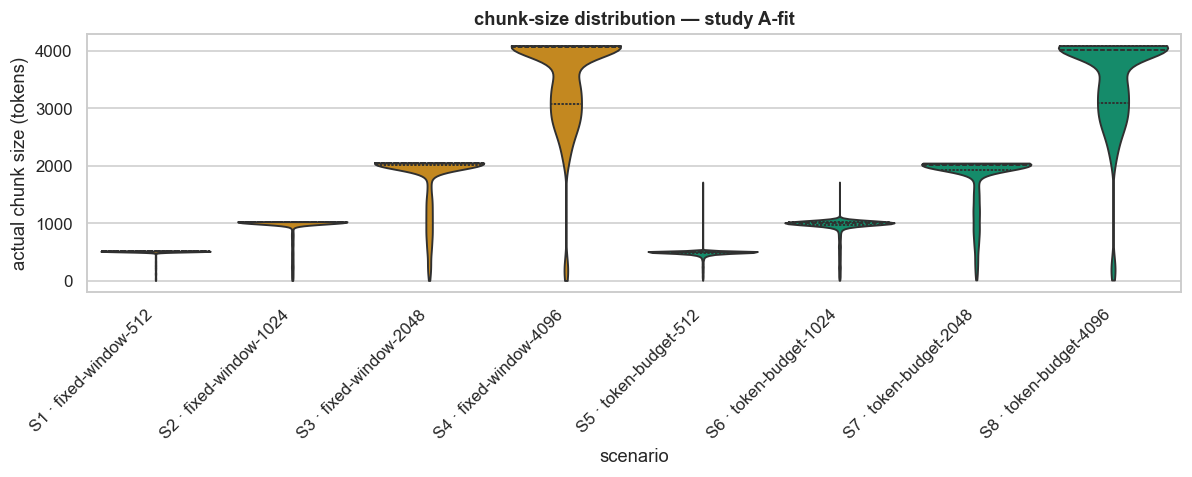

In [21]:
chunk_rows = []
for sid, pool in inputs.pools.items():
    if pool.scenario.chunker_name is None:
        continue
    target = pool.scenario.chunk_tokens
    for per_chunk in pool.n_tokens_per_chunk:
        for tok in per_chunk:
            chunk_rows.append({
                "scenario_id": sid,
                "scenario_display": SCENARIO_LABELS[sid],
                "chunker": pool.scenario.chunker_name,
                "chunk_tokens_target": target,
                "actual": int(tok),
            })
chunk_df = pd.DataFrame.from_records(chunk_rows)

if chunk_df.empty:
    print("No chunked scenarios in this study (all scenarios are S0?).")
else:
    summary = (
        chunk_df.groupby(["scenario_id", "scenario_display", "chunker", "chunk_tokens_target"])
        ["actual"]
        .agg(["count", "mean", "std", "min", "max",
              ("stub_count", lambda s: int((s < 256).sum()))])
        .reset_index()
    )
    summary["padding_pct"] = (
        (summary["chunk_tokens_target"] - summary["mean"])
        / summary["chunk_tokens_target"] * 100
    ).round(1)
    summary["cv"] = (summary["std"] / summary["mean"]).round(3)
    print("chunk-size distribution per scenario")
    print(summary[[
        "scenario_id", "chunker", "chunk_tokens_target", "count",
        "mean", "stub_count", "padding_pct", "cv"
    ]].round(1).to_string(index=False))
    print()

    chunked_order = [
        SCENARIO_LABELS[s] for s in SCENARIO_ORDER
        if s in chunk_df["scenario_id"].unique()
    ]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    sns.violinplot(
        data=chunk_df,
        x="scenario_display",
        y="actual",
        order=chunked_order,
        hue="chunker",
        hue_order=[c for c in CHUNKER_ORDER if c != "truncate"],
        palette={k: v for k, v in chunker_palette.items() if k != "truncate"},
        ax=ax,
        cut=0,
        density_norm="width",
        inner="quartile",
        legend=False,
    )
    ax.set_xlabel("scenario")
    ax.set_ylabel("actual chunk size (tokens)")
    ax.set_title(f"chunk-size distribution — study {study_cfg.study.name}")
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment("right")
    fig.tight_layout()
    plt.show()